# Lab 3: Attention-based NMT

In [26]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Implement Attention

In [27]:
class DotAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, query, keys, mask=None):
        # query: [batch, hidden], keys: [batch, src_len, hidden]
        scores = torch.bmm(keys, query.unsqueeze(2)).squeeze(2)
        if mask is not None:
            scores = scores.masked_fill(~mask, float("-inf"))

        attn_weights = F.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), keys).squeeze(1)
        return context, attn_weights

## Prepare Data

In [28]:
SPECIALS = ["<pad>", "<bos>", "<eos>", "<unk>"]
PAD, BOS, EOS, UNK = SPECIALS


def tokenize(text):
    return text.strip().lower().split()


def build_vocab(sentences, min_freq=2):
    freq = {}
    for s in sentences:
        for tok in tokenize(s):
            freq[tok] = freq.get(tok, 0) + 1

    itos = SPECIALS.copy()
    for tok, c in sorted(freq.items(), key=lambda x: (-x[1], x[0])):
        if c >= min_freq:
            itos.append(tok)

    stoi = {tok: i for i, tok in enumerate(itos)}
    return stoi, itos


def encode_sentence(sentence, stoi):
    ids = [stoi[BOS]]
    ids.extend(stoi.get(tok, stoi[UNK]) for tok in tokenize(sentence))
    ids.append(stoi[EOS])
    return torch.tensor(ids, dtype=torch.long)


def resolve_or_download_data_dir():
    # Try common local paths first (works in VS Code/Jupyter local).
    candidate_dirs = [
        Path("data"),
        Path("NLP Lab 3_ Attention-based Neural Machine Translation") / "data",
        Path("Seq2Seq-Attention") / "NLP Lab 3_ Attention-based Neural Machine Translation" / "data",
        Path("/content") / "data",
        Path("/content") / "Seq2Seq-Attention" / "NLP Lab 3_ Attention-based Neural Machine Translation" / "data",
    ]

    required_files = ["train.en", "train.vi", "dev.en", "dev.vi"]

    for d in candidate_dirs:
        if all((d / f).exists() for f in required_files):
            return d

    # Fallback for Google Colab opened directly from GitHub notebook link.
    data_dir = Path("data")
    data_dir.mkdir(parents=True, exist_ok=True)

    from urllib.request import urlretrieve

    base_url = (
        "https://raw.githubusercontent.com/dangnt-courses/hands-on-projects/main/"
        "Seq2Seq-Attention/NLP%20Lab%203_%20Attention-based%20Neural%20Machine%20Translation/data"
    )

    for f in required_files:
        target = data_dir / f
        if not target.exists():
            urlretrieve(f"{base_url}/{f}", str(target))

    if all((data_dir / f).exists() for f in required_files):
        return data_dir

    raise FileNotFoundError(
        "Could not locate Lab 3 data files. Expected: train.en, train.vi, dev.en, dev.vi."
    )


base_dir = resolve_or_download_data_dir()
train_en_lines = (base_dir / "train.en").read_text(encoding="utf-8").splitlines()
train_vi_lines = (base_dir / "train.vi").read_text(encoding="utf-8").splitlines()

max_samples = len(train_en_lines)
pairs = list(zip(train_en_lines, train_vi_lines))[:max_samples]

src_stoi, src_itos = build_vocab([p[0] for p in pairs], min_freq=2)
tgt_stoi, tgt_itos = build_vocab([p[1] for p in pairs], min_freq=1)

src_pad_idx = src_stoi[PAD]
tgt_pad_idx = tgt_stoi[PAD]


dataset = [(encode_sentence(src, src_stoi), encode_sentence(tgt, tgt_stoi)) for src, tgt in pairs]

split = int(0.9 * len(dataset))
train_data = dataset[:split]
valid_data = dataset[split:]


def collate_fn(batch):
    src_batch = [x[0] for x in batch]
    tgt_batch = [x[1] for x in batch]
    src_pad = pad_sequence(src_batch, batch_first=True, padding_value=src_pad_idx)
    tgt_pad = pad_sequence(tgt_batch, batch_first=True, padding_value=tgt_pad_idx)
    return src_pad.to(device), tgt_pad.to(device)


train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_data, batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f"Data dir: {base_dir}")
print(f"Train pairs: {len(train_data)} | Valid pairs: {len(valid_data)}")
print(f"Src vocab: {len(src_itos)} | Tgt vocab: {len(tgt_itos)}")

Data dir: data
Train pairs: 9 | Valid pairs: 1
Src vocab: 11 | Tgt vocab: 13


## Build Attention-based Seq2Seq

In [29]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=src_pad_idx)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.dropout(self.embedding(src))
        outputs, hidden = self.gru(emb)
        return outputs, hidden


class AttentiveDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, dropout=0.2):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=tgt_pad_idx)
        self.attn = DotAttention()
        self.gru = nn.GRU(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim + hidden_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs, src_mask):
        # input_token: [batch]
        emb = self.dropout(self.embedding(input_token)).unsqueeze(1)  # [batch, 1, emb]

        query = hidden[-1]  # [batch, hidden]
        context, attn_weights = self.attn(query, encoder_outputs, mask=src_mask)
        context_step = context.unsqueeze(1)  # [batch, 1, hidden]

        gru_input = torch.cat([emb, context_step], dim=2)
        output, hidden = self.gru(gru_input, hidden)

        out = output.squeeze(1)
        logits = self.fc(torch.cat([out, context, emb.squeeze(1)], dim=1))
        return logits, hidden, attn_weights


class Seq2SeqAttn(nn.Module):
    def __init__(self, encoder, decoder, tgt_pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_pad_idx = tgt_pad_idx

    def make_src_mask(self, src):
        return src.ne(src_pad_idx)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src.device)
        attn_scores = []

        encoder_outputs, hidden = self.encoder(src)
        src_mask = self.make_src_mask(src)

        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, attn_w = self.decoder(input_token, hidden, encoder_outputs, src_mask)
            outputs[:, t] = logits
            attn_scores.append(attn_w)

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(dim=1)
            input_token = tgt[:, t] if teacher_force else top1

        if attn_scores:
            attn_scores = torch.stack(attn_scores, dim=1)
        else:
            attn_scores = torch.zeros(batch_size, 0, src.size(1), device=src.device)

        return outputs, attn_scores

    @torch.no_grad()
    def greedy_decode(self, src, max_len=40):
        self.eval()
        encoder_outputs, hidden = self.encoder(src)
        src_mask = self.make_src_mask(src)

        batch_size = src.size(0)
        input_token = torch.full((batch_size,), tgt_stoi[BOS], dtype=torch.long, device=src.device)

        generated = [input_token]
        all_attn = []

        for _ in range(max_len):
            logits, hidden, attn_w = self.decoder(input_token, hidden, encoder_outputs, src_mask)
            input_token = logits.argmax(dim=1)
            generated.append(input_token)
            all_attn.append(attn_w)

        tokens = torch.stack(generated, dim=1)
        attn = torch.stack(all_attn, dim=1)
        return tokens, attn

## Train Model

In [30]:
input_dim = len(src_itos)
output_dim = len(tgt_itos)
emb_dim = 192
hidden_dim = 192

epochs = 20
learning_rate = 8e-4
weight_decay = 1e-4
patience = 4

encoder = Encoder(input_dim, emb_dim, hidden_dim, dropout=0.3).to(device)
decoder = AttentiveDecoder(output_dim, emb_dim, hidden_dim, dropout=0.3).to(device)
model = Seq2SeqAttn(encoder, decoder, tgt_pad_idx=tgt_pad_idx).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=tgt_pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-5
)


def train_epoch(model, dataloader):
    model.train()
    total_loss = 0.0

    for src, tgt in dataloader:
        optimizer.zero_grad()
        logits, _ = model(src, tgt, teacher_forcing_ratio=0.5)

        # Skip t=0 because it is BOS token.
        pred = logits[:, 1:].reshape(-1, logits.size(-1))
        gold = tgt[:, 1:].reshape(-1)

        loss = criterion(pred, gold)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(dataloader), 1)


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0.0

    for src, tgt in dataloader:
        logits, _ = model(src, tgt, teacher_forcing_ratio=0.0)
        pred = logits[:, 1:].reshape(-1, logits.size(-1))
        gold = tgt[:, 1:].reshape(-1)
        loss = criterion(pred, gold)
        total_loss += loss.item()

    return total_loss / max(len(dataloader), 1)


best_valid_loss = float("inf")
best_state_dict = None
best_epoch = 0
wait = 0

for epoch in range(1, epochs + 1):
    train_loss = train_epoch(model, train_loader)
    valid_loss = evaluate(model, valid_loader)
    scheduler.step(valid_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}"
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(
                f"Early stopping at epoch {epoch:02d} | Best Valid Loss: {best_valid_loss:.4f} at epoch {best_epoch:02d}"
            )
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    model.to(device)
    print(f"Loaded best model from epoch {best_epoch:02d} with Valid Loss: {best_valid_loss:.4f}")

Epoch 01 | LR: 0.000800 | Train Loss: 2.5155 | Valid Loss: 1.8582
Epoch 02 | LR: 0.000800 | Train Loss: 2.1917 | Valid Loss: 1.5871
Epoch 03 | LR: 0.000800 | Train Loss: 1.9513 | Valid Loss: 1.4243
Epoch 04 | LR: 0.000800 | Train Loss: 1.8227 | Valid Loss: 1.3526
Epoch 05 | LR: 0.000800 | Train Loss: 1.7323 | Valid Loss: 1.3527
Epoch 06 | LR: 0.000800 | Train Loss: 1.6313 | Valid Loss: 1.3467
Epoch 07 | LR: 0.000800 | Train Loss: 1.6283 | Valid Loss: 1.3674
Epoch 08 | LR: 0.000800 | Train Loss: 1.5585 | Valid Loss: 1.5115
Epoch 09 | LR: 0.000400 | Train Loss: 1.4833 | Valid Loss: 1.6836
Epoch 10 | LR: 0.000400 | Train Loss: 1.4502 | Valid Loss: 1.6649
Early stopping at epoch 10 | Best Valid Loss: 1.3467 at epoch 06
Loaded best model from epoch 06 with Valid Loss: 1.3467


## Attention Visualization

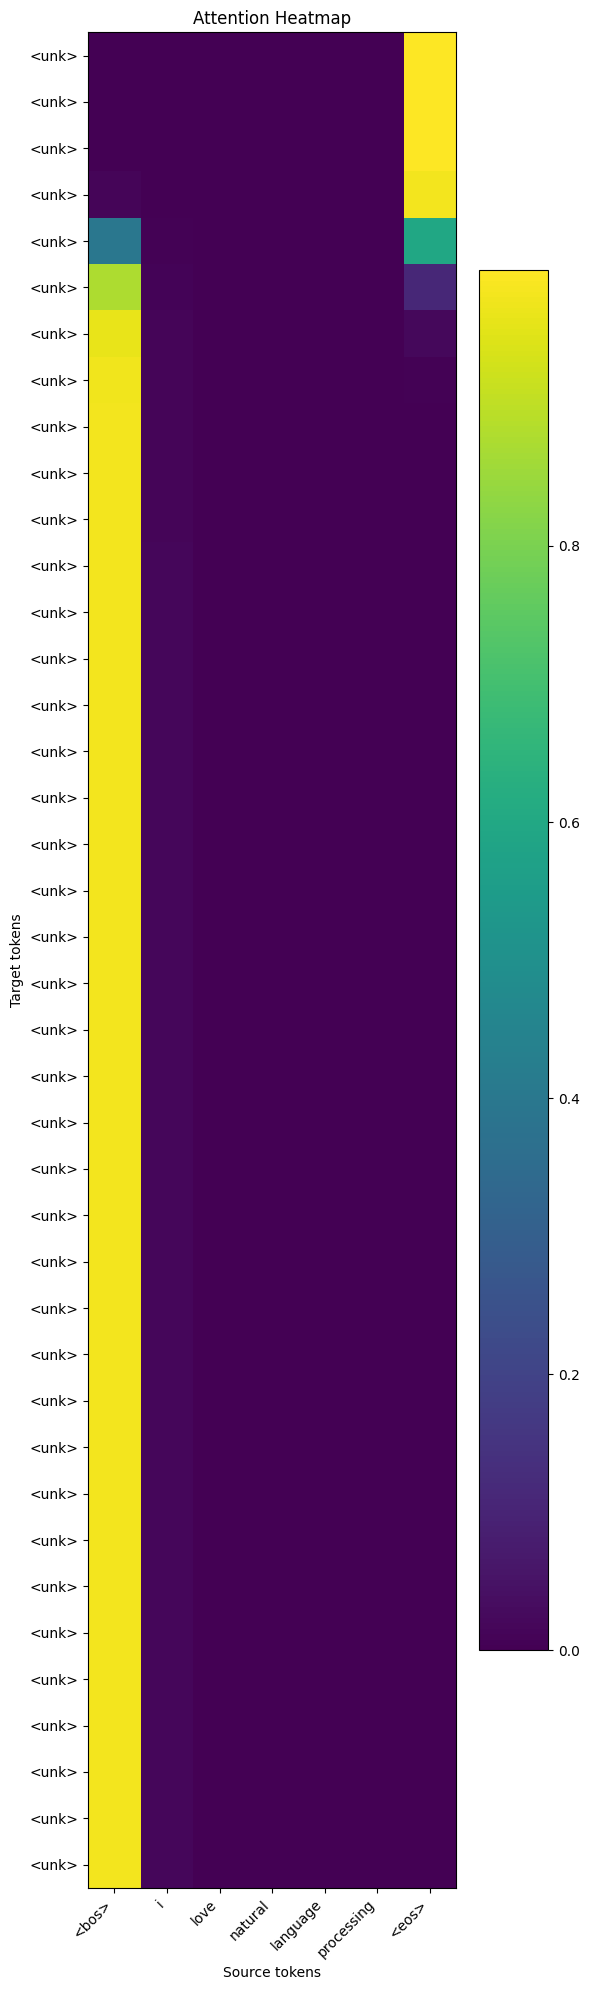

Source: i love natural language processing
Prediction: <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>


In [31]:
def ids_to_tokens(ids, itos):
    toks = []
    for i in ids:
        tok = itos[i]
        toks.append(tok)
        if tok == EOS:
            break
    return toks


@torch.no_grad()
def translate_and_plot(model, src_sentence):
    src_tensor = encode_sentence(src_sentence, src_stoi).unsqueeze(0).to(device)
    pred_ids, attn = model.greedy_decode(src_tensor, max_len=40)

    src_tokens = [BOS] + tokenize(src_sentence) + [EOS]
    tgt_ids = pred_ids[0].tolist()
    tgt_tokens = ids_to_tokens(tgt_ids[1:], tgt_itos)

    eos_positions = [i for i, t in enumerate(tgt_tokens) if t == EOS]
    tgt_len = eos_positions[0] + 1 if eos_positions else len(tgt_tokens)

    attn_map = attn[0, :tgt_len, : len(src_tokens)].cpu().numpy()

    plt.figure(figsize=(max(6, len(src_tokens) * 0.6), max(4, tgt_len * 0.5)))
    plt.imshow(attn_map, aspect="auto", cmap="viridis")
    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right")
    plt.yticks(range(tgt_len), tgt_tokens[:tgt_len])
    plt.xlabel("Source tokens")
    plt.ylabel("Target tokens")
    plt.title("Attention Heatmap")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    print("Source:", src_sentence)
    print("Prediction:", " ".join(t for t in tgt_tokens if t not in {BOS, EOS, PAD}))


sample_src = "i love natural language processing"
translate_and_plot(model, sample_src)